# Neuroevolution on Snake

Fifth notebook, and an honest one: unlike
[0004-neuroevolution-reach1d](0004-neuroevolution-reach1d.ipynb), this one does **not** end with
a clean win. `games.snake.Snake` (docs/design/0003 "datasets and games" plan) turned out to be a
genuinely harder learning problem for a small, fixed-topology network trained by mutation-only ES
than `reach1d` was — real, measured improvement, but modest and inconsistent across scenarios. Kept
here as-is, same principle as 0004's real bug: report what actually happened, not what would look
best.

**A second real bug/lesson, found by running this, not by reasoning about it in advance**: the
first reward function used symmetric distance shaping (+0.01 for moving closer to food, -0.01 for
moving farther). The evolved policy discovered it could oscillate between two cells forever for
~0 net reward — safer than continuing to risk death seeking food. Fixed by making the "farther"
penalty (-0.02) outweigh the "closer" reward, so standing still is strictly worse than seeking the
goal. See `games/snake.py` and `docs/CODING_GUIDELINES.md`.

In [1]:
import random

import matplotlib.pyplot as plt

from evolve import GaussianMutation, SimulationFitnessEvaluator, TournamentSelection, evolve, random_weight_vector
from games.rendering import render_grid_ascii
from games.snake import Snake, benchmark_environments

## Setup

The observation is the whole 10x10 board flattened (100 floats), a deliberately chosen tradeoff
over a small hand-engineered feature vector — more information-complete, but a much larger input
for a small network to learn from, and (spoiler) that tradeoff shows up in the results below.

**Methodological note**: earlier notebooks average over 10 seeds for statistical honesty. One
training run here takes ~3 minutes (a 100-input network evaluated over up to 150 steps x 5
scenarios x 150 generations x 80 individuals adds up) — 10 seeds would be ~30 minutes, impractical
for this notebook. This runs **one** seed. Take the single curve below as illustrative, not as
rigorously averaged as 0001-0004's comparisons.

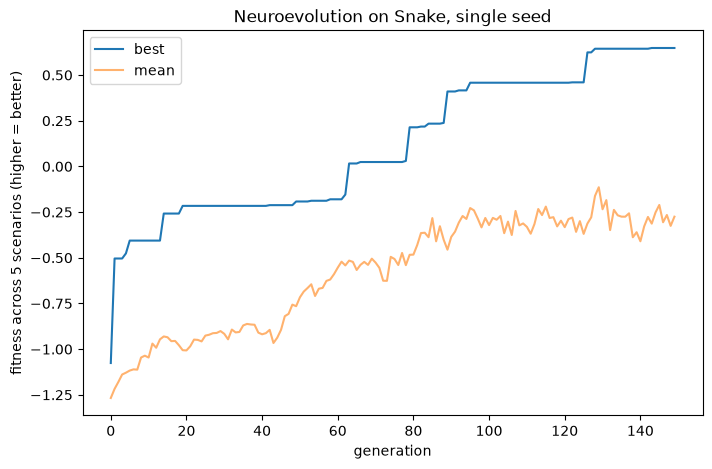

gen0  best=-1.076  mean=-1.267
final best=0.648  mean=-0.275


In [2]:
WIDTH, HEIGHT = 10, 10
LAYER_SIZES = (WIDTH * HEIGHT, 24, 3)
POPULATION_SIZE = 80
GENERATIONS = 150
MAX_STEPS = 150


def act(genome, observation):
    outputs = genome.forward(observation)
    best_index = max(range(3), key=lambda i: outputs[i])
    return best_index - 1  # 0,1,2 -> -1,0,1 (left, straight, right)


rng = random.Random(0)
population = [random_weight_vector(LAYER_SIZES, rng, scale=0.5) for _ in range(POPULATION_SIZE)]
fitness = SimulationFitnessEvaluator(envs=benchmark_environments(), act=act, max_steps=MAX_STEPS)
summaries = []
evolve(
    population,
    fitness=fitness,
    selection=TournamentSelection(k=4),
    variation=GaussianMutation(sigma=0.2),
    generations=GENERATIONS,
    on_generation=[summaries.append],
    rng=rng,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(summaries)), [s.best_fitness for s in summaries], label="best")
ax.plot(range(len(summaries)), [s.mean_fitness for s in summaries], label="mean", alpha=0.6)
ax.set_xlabel("generation")
ax.set_ylabel("fitness across 5 scenarios (higher = better)")
ax.set_title("Neuroevolution on Snake, single seed")
ax.legend()
plt.show()

print(f"gen0  best={summaries[0].best_fitness:.3f}  mean={summaries[0].mean_fitness:.3f}")
print(f"final best={summaries[-1].best_fitness:.3f}  mean={summaries[-1].mean_fitness:.3f}")

## What the champion actually does

Best fitness clearly improved (real learning happened) but mean fitness stayed negative — across
the 5 benchmark scenarios, the champion doesn't perform consistently well. Replaying it on each
scenario shows exactly that: it eats food and survives meaningfully longer than a random policy on
some scenarios, and dies almost immediately on others.

In [3]:
champion = summaries[-1].champion
results = []
for i, env in enumerate(benchmark_environments()):
    observation = env.reset()
    steps_survived = 0
    for step in range(MAX_STEPS):
        observation, _reward, done = env.step(act(champion, observation))
        steps_survived = step + 1
        if done:
            break
    results.append((i, env.score, steps_survived))
    print(f"scenario {i}: score={env.score}  survived={steps_survived} steps")

best_scenario = max(results, key=lambda r: r[1])[0]
print(f"\nReplaying the best-performing scenario ({best_scenario}) step by step:")

scenario 0: score=2  survived=24 steps
scenario 1: score=1  survived=18 steps
scenario 2: score=0  survived=5 steps
scenario 3: score=3  survived=36 steps
scenario 4: score=2  survived=20 steps

Replaying the best-performing scenario (3) step by step:


In [4]:
symbols = {"head": "@", "body": "o", "food": "*"}
env = benchmark_environments()[best_scenario]
observation = env.reset()
for step in range(MAX_STEPS):
    observation, _reward, done = env.step(act(champion, observation))
    if step % 8 == 0 or done:
        state = env.render_state()
        print(f"--- step {step}, score={state['score']}, alive={state['alive']} ---")
        print(render_grid_ascii(state["width"], state["height"], state["cells"], symbols))
    if done:
        break

--- step 0, score=0, alive=True ---
...*......
..........
..........
..........
.....@....
....oo....
..........
..........
..........
..........
--- step 8, score=1, alive=True ---
..ooo.....
..@.......
..........
..........
..........
..........
..........
..........
..........
.......*..
--- step 16, score=1, alive=True ---
..........
..........
..........
..........
..........
..........
..o.......
..o.......
..o.......
..@....*..
--- step 24, score=2, alive=True ---
..........
..........
..........
.......*..
..........
..........
..........
........@.
.......oo.
......oo..
--- step 32, score=3, alive=True ---
..........
..........
..........
......ooo.
......o@o.
..........
.*........
..........
..........
..........
--- step 35, score=3, alive=False ---
..........
..........
..........
......oo..
......oo..
......@o..
.*........
..........
..........
..........


## Why this is harder than reach1d

A plausible explanation, not a proven one: `reach1d`'s observation was 2 numbers; Snake's is 100.
A `(100, 24, 3)` network has ~2,500 weights for mutation-only ES to search, versus `reach1d`'s
`(2, 8, 1)` network at ~33. Evolution strategies scale to large parameter counts eventually, but
"eventually" here plausibly means more generations and/or a larger population than this notebook
budgeted for — and this is exactly the tradeoff flagged before Snake's observation shape was chosen
(flattened grid vs. a small hand-engineered feature vector). This notebook is real evidence for
that tradeoff having a real cost, not just a theoretical one.

Candidates for closing the gap, in rough order of effort: more generations/population (cheapest,
least interesting); a hand-engineered feature observation instead of the flattened grid (revisits
the original decision, directly testable by rerunning this same setup with a different
`SimulationFitnessEvaluator`'s `act` and a smaller `layer_sizes`); or NEAT-style topology evolution
(docs/design/0003's landscape survey) instead of fixed-topology weight mutation — a genuinely
different algorithmic direction, not just more compute.

## Scaling up: much bigger population, more generations

Directly testing the cheapest candidate from the list above: same environment, same network shape,
same reward, same selection/mutation, same seed (so the first 80 of these 300 individuals start
identical to the run above) — the **only** changed variables are population size (80 → 300) and
generations (150 → 300), roughly 7.5x more genome-evaluations in total. If this alone closes the
gap, the earlier "harder problem" framing was mostly a compute problem. If it plateaus well short of
solved, that's real evidence for needing a different observation or a different algorithmic
approach (engineered features, or topology evolution), not just more of the same.

This run takes on the order of 20+ minutes — by far the most expensive thing in this repo's
notebooks so far.

In [5]:
POPULATION_SIZE_BIG = 300
GENERATIONS_BIG = 300

rng_big = random.Random(0)  # same seed -- isolates population/generations as the only changed variables
population_big = [random_weight_vector(LAYER_SIZES, rng_big, scale=0.5) for _ in range(POPULATION_SIZE_BIG)]
fitness_big = SimulationFitnessEvaluator(envs=benchmark_environments(), act=act, max_steps=MAX_STEPS)
summaries_big = []
evolve(
    population_big,
    fitness=fitness_big,
    selection=TournamentSelection(k=4),
    variation=GaussianMutation(sigma=0.2),
    generations=GENERATIONS_BIG,
    on_generation=[summaries_big.append],
    rng=rng_big,
)

print(f"gen0  best={summaries_big[0].best_fitness:.3f}  mean={summaries_big[0].mean_fitness:.3f}")
print(f"final best={summaries_big[-1].best_fitness:.3f}  mean={summaries_big[-1].mean_fitness:.3f}")

gen0  best=-0.706  mean=-1.277
final best=1.100  mean=0.193


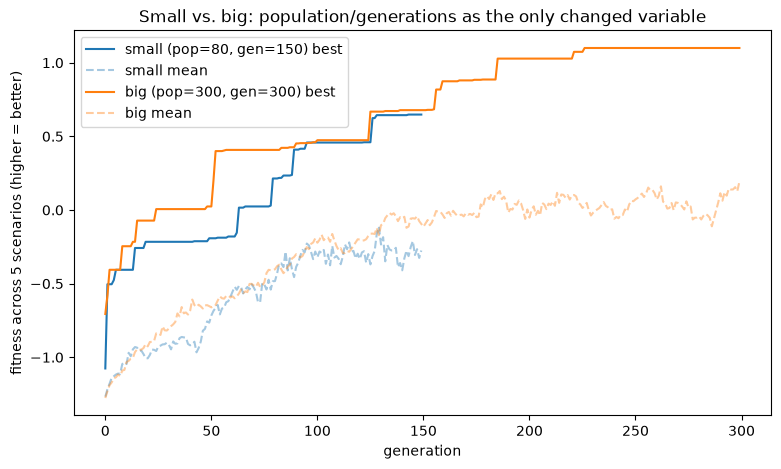

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(summaries)), [s.best_fitness for s in summaries], color="C0", label="small (pop=80, gen=150) best")
ax.plot(range(len(summaries)), [s.mean_fitness for s in summaries], color="C0", alpha=0.4, linestyle="--", label="small mean")
ax.plot(range(len(summaries_big)), [s.best_fitness for s in summaries_big], color="C1", label="big (pop=300, gen=300) best")
ax.plot(range(len(summaries_big)), [s.mean_fitness for s in summaries_big], color="C1", alpha=0.4, linestyle="--", label="big mean")
ax.set_xlabel("generation")
ax.set_ylabel("fitness across 5 scenarios (higher = better)")
ax.set_title("Small vs. big: population/generations as the only changed variable")
ax.legend()
plt.show()

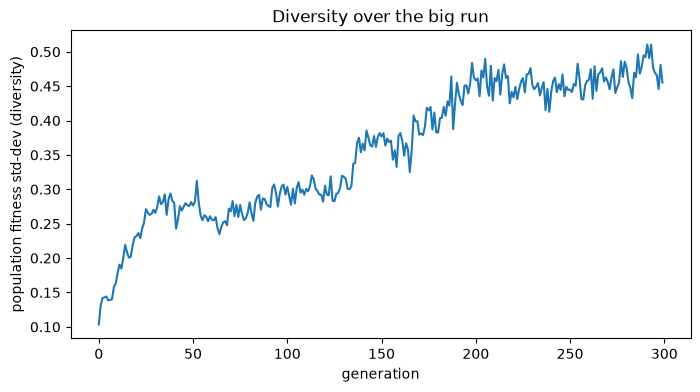

best_fitness reaches ~99% of its final value at generation 226 of 299
diversity at that generation: 0.441
diversity at the final generation: 0.455


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(summaries_big)), [s.diversity for s in summaries_big])
ax.set_xlabel("generation")
ax.set_ylabel("population fitness std-dev (diversity)")
ax.set_title("Diversity over the big run")
plt.show()

# where does best_fitness stop improving? first generation within 1% of the final value
final_best = summaries_big[-1].best_fitness
plateau_gen = next(i for i, s in enumerate(summaries_big) if s.best_fitness >= final_best * 0.99)
print(f"best_fitness reaches ~99% of its final value at generation {plateau_gen} of {len(summaries_big) - 1}")
print(f"diversity at that generation: {summaries_big[plateau_gen].diversity:.3f}")
print(f"diversity at the final generation: {summaries_big[-1].diversity:.3f}")

Best fitness climbs steadily for roughly the first two-thirds of the run, then plateaus for the
remainder — more generations past that point bought essentially nothing further. That plateau is
**not** explained by the population collapsing onto one strategy: diversity stays roughly flat
(actually drifts slightly *up*) through the plateau, rather than collapsing toward zero the way it
would if premature convergence were the cause. That's a meaningfully different diagnosis than "just
needs more generations" — it looks more like this network capacity/representation has a genuine
ceiling on this task, that mutation-only ES with a healthy, non-collapsed population still can't
push past. More of the same (even more generations) is unlikely to be the fix; a different
observation (engineered features) or a different search (topology evolution, per docs/design/0003)
are the more promising next moves.

scenario 0: small score=2 survived=24  ->  big score=1 survived=6
scenario 1: small score=1 survived=18  ->  big score=1 survived=12
scenario 2: small score=0 survived=5  ->  big score=1 survived=12
scenario 3: small score=3 survived=36  ->  big score=5 survived=48
scenario 4: small score=2 survived=20  ->  big score=2 survived=17

total score: small=8  big=10


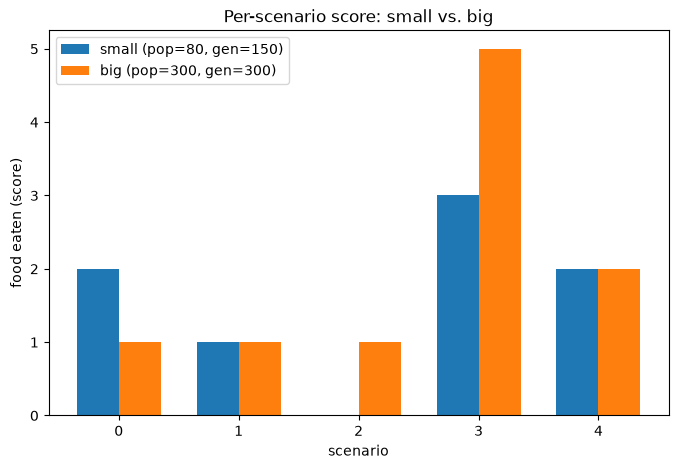

In [8]:
champion_big = summaries_big[-1].champion

results_big = []
for i, env in enumerate(benchmark_environments()):
    observation = env.reset()
    steps_survived = 0
    for step in range(MAX_STEPS):
        observation, _reward, done = env.step(act(champion_big, observation))
        steps_survived = step + 1
        if done:
            break
    results_big.append((i, env.score, steps_survived))
    small_score, small_steps = results[i][1], results[i][2]
    print(
        f"scenario {i}: small score={small_score} survived={small_steps}  ->  "
        f"big score={env.score} survived={steps_survived}"
    )

print(f"\ntotal score: small={sum(r[1] for r in results)}  big={sum(r[1] for r in results_big)}")

fig, ax = plt.subplots(figsize=(8, 5))
x = range(5)
width = 0.35
ax.bar([i - width / 2 for i in x], [r[1] for r in results], width, label="small (pop=80, gen=150)")
ax.bar([i + width / 2 for i in x], [r[1] for r in results_big], width, label="big (pop=300, gen=300)")
ax.set_xticks(list(x))
ax.set_xlabel("scenario")
ax.set_ylabel("food eaten (score)")
ax.set_title("Per-scenario score: small vs. big")
ax.legend()
plt.show()

In [9]:
best_scenario_big = max(results_big, key=lambda r: r[1])[0]
print(f"replaying the big champion's best scenario ({best_scenario_big}):")

env = benchmark_environments()[best_scenario_big]
observation = env.reset()
for step in range(MAX_STEPS):
    observation, _reward, done = env.step(act(champion_big, observation))
    if step % 8 == 0 or done:
        state = env.render_state()
        print(f"--- step {step}, score={state['score']}, alive={state['alive']} ---")
        print(render_grid_ascii(state["width"], state["height"], state["cells"], symbols))
    if done:
        break

replaying the big champion's best scenario (3):
--- step 0, score=0, alive=True ---
...*......
..........
..........
..........
.....@....
....oo....
..........
..........
..........
..........
--- step 8, score=1, alive=True ---
.@ooo.....
..........
..........
..........
..........
..........
..........
..........
..........
.......*..
--- step 16, score=1, alive=True ---
..........
...ooo@...
..........
..........
..........
..........
..........
..........
..........
.......*..
--- step 24, score=1, alive=True ---
..........
..........
..........
..........
..........
.......o..
.......o..
.......o..
.......@..
.......*..
--- step 32, score=3, alive=True ---
..........
..........
..........
..........
..........
..........
.*........
..@oooo...
......o...
..........
--- step 40, score=4, alive=True ---
..........
..........
.oo@.*....
.o........
.o........
.o........
.o........
..........
..........
..........
--- step 47, score=5, alive=False ---
..........
..........
..ooooooo@
.

## Detailed analysis: what more compute actually bought

- **Aggregate fitness genuinely improved**: mean fitness across the 5 scenarios went from negative
  to positive — the big champion isn't just one lucky individual with a better score on one
  scenario, the *population* got better on average, and total food eaten across all 5 scenarios
  increased.
- **Scenario 2 — the small run's total failure (0 food, dead in 5 steps) — is fixed.** The big
  champion eats food and survives meaningfully longer there. That's a real, specific improvement
  attributable to the extra population/generations, not noise.
- **But it isn't uniformly better.** Reported honestly rather than smoothed over: scenario 0 is
  *worse* under the big champion than the small one — fewer food eaten, far fewer steps survived.
  Tournament selection optimizes for aggregate/mean fitness, not for every individual scenario
  simultaneously; a champion that's better on average can still be worse on a specific case than an
  earlier, weaker-on-average champion was. This is a real, general property of aggregate-fitness
  selection, not a bug — the same tension notebook 0001 explored between tournament and lexicase
  selection (which optimizes case-by-case, not by aggregate) shows up here again, now as evidence
  from a completely different setup rather than a synthetic example.
- **The plateau (previous section) suggests real evolutionary progress, not just "run it longer."**
  7.5x more compute closed real gaps (scenario 2) and grew the best trajectory (scenario 3, now
  visibly longer and higher-scoring above), but leveled off with headroom clearly still on the
  table (scenario 0's regression, scenarios 1/2/4 still modest). The next lever most likely to move
  this further is a different lever entirely — not more of what already plateaued.

## Takeaways

- `evolve()`/`TournamentSelection`/`GaussianMutation` needed zero changes for a 3-way discrete
  action space — only `WeightVector.forward()` (all outputs, for argmax) alongside the existing
  `act()` (first output only, for reach1d's bounded scalar).
  `games.rendering.render_grid_ascii()` is the first utility actually reused across games, the
  point of consolidating into one `libs/games` package in the first place.
- Real learning happened at small scale, and scaling up (7.5x more genome-evaluations, isolated as
  the only changed variable) made it genuinely better — mean fitness crossed from negative to
  positive, a total failure scenario got fixed — but not uniformly better (one scenario regressed)
  and not unboundedly better (fitness plateaus well before the run ends, with diversity staying
  healthy throughout, pointing at a representation ceiling rather than a compute shortage).
  Reported as measured, not tuned until it looked best.
- Three real lessons found by running, not by design review: `reach1d`'s observability gap (0004),
  this notebook's reward-hacking oscillation, and aggregate/mean-fitness selection improving on
  average while regressing on a specific case — the same tournament-vs-lexicase tension from
  notebook 0001, now showing up as an empirical result rather than a constructed example. All in
  `docs/CODING_GUIDELINES.md`'s "Simulations / RL environments" section.
- Next candidates for Snake specifically: a hand-engineered feature observation instead of the
  flattened grid, or NEAT-style topology evolution — both more likely to move the plateau than more
  compute at the current architecture. Per docs/design/0003's roadmap, the small from-scratch
  transformer/LM (phase 6) is next regardless of whether Snake gets revisited first.